Class Proportions:
Malignant: 5590 Benign: 6289


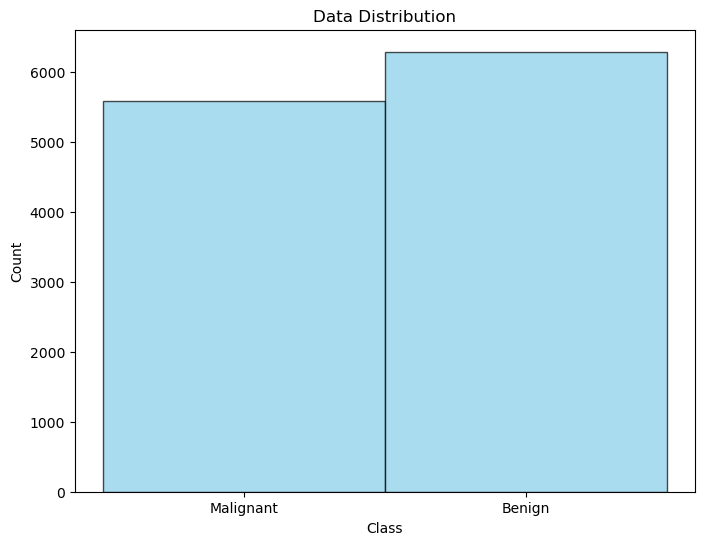

In [8]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Define constants
data_path = r"C:\Users\pooji\Downloads\archive\train"
target_size = (224, 224)  # Define the target size for resizing

# Load and preprocess data
images = []
labels = []

# Loop through each class (Malignant and Benign)
for class_name in ['Malignant', 'Benign']:
    class_path = os.path.join(data_path, class_name)
    # Iterate through each image in the class
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        # Read the image in grayscale
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        # Resize the image to the target size
        img = cv2.resize(img, target_size)
        # Normalize the pixel values to the range [0, 1]
        img = img.astype(np.float32) / 255.0
        # Append the preprocessed image to the images list
        images.append(img)
        # Append the label (0 for Malignant, 1 for Benign) to the labels list
        labels.append(0 if class_name == 'Malignant' else 1)

# Convert images and labels to NumPy arrays
images = np.array(images)
labels = np.array(labels)

# Print class proportions
print("Class Proportions:")
print("Malignant:", np.sum(labels == 0), "Benign:", np.sum(labels == 1))

# Plot histogram for class distribution
plt.figure(figsize=(8, 6))
plt.hist(labels, bins=2, color='skyblue', edgecolor='black', alpha=0.7)
plt.xticks([0.25, 0.75], ['Malignant', 'Benign'])
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Data Distribution')
plt.show()


In [9]:
# Separate data for Malignant and Benign classes
malignant_images = images[labels == 0][:1000]
benign_images = images[labels == 1][:1000]
malignant_labels = labels[labels == 0][:1000]
benign_labels = labels[labels == 1][:1000]

# Concatenate the data back together
balanced_images = np.concatenate([malignant_images, benign_images])
balanced_labels = np.concatenate([malignant_labels, benign_labels])

# Split the balanced dataset into training and testing sets

# Split the data into training and testing sets
X_train_full, X_test, y_train_full, y_test = train_test_split(balanced_images, balanced_labels, test_size=0.2, random_state=42)

# Split the training data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, test_size=0.1, random_state=42)


#print the balanced data
print("Balanced Images:", balanced_images.shape)
print("Balanced labels:", balanced_labels.shape)

#print the data separately of each class
print("malignant_images:", malignant_images.shape)
print("benign_images:", benign_images.shape)

# Print the shapes of the training and testing sets
print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("y_valid shape:", y_valid.shape)


Balanced Images: (2000, 224, 224)
Balanced labels: (2000,)
malignant_images: (1000, 224, 224)
benign_images: (1000, 224, 224)
X_train shape: (1440, 224, 224)
X_valid shape: (160, 224, 224)
X_test shape: (400, 224, 224)
y_train shape: (1440,)
y_test shape: (400,)
y_valid shape: (160,)


In [4]:
pip install pyswarm


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for pyswarm: filename=pyswarm-0.6-py3-none-any.whl size=4485 sha256=5b948e7106fbfed0849b583f8adc763e2b2f8151700cba51b31f211cf27ddecf
  Stored in directory: c:\users\pooji\appdata\local\pip\cache\wheels\3a\dc\85\708c16bc4b8ee614c5e8aa10f24a4574dee291822622df7df7
Successfully built pyswarm
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import cv2
import time
from pyswarm import pso
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, cohen_kappa_score, matthews_corrcoef, balanced_accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split

# Assuming you have X_train, X_test, y_train, and y_test defined

# Modify the data shapes based on the model requirements
X_train_resized = np.array([cv2.resize(img, (224, 224)) for img in X_train])
X_train_resized = np.repeat(X_train_resized[..., np.newaxis], 3, -1)
X_valid_resized = np.array([cv2.resize(img, (224, 224)) for img in X_valid])
X_valid_resized = np.repeat(X_valid_resized[..., np.newaxis], 3, -1)
X_test_resized = np.array([cv2.resize(img, (224, 224)) for img in X_test])
X_test_resized = np.repeat(X_test_resized[..., np.newaxis], 3, -1)

# Split the data into training and validation sets
X_train_split, X_valid_split, y_train_split, y_valid_split = train_test_split(X_train_resized, y_train, test_size=0.2, random_state=42)

# Define the PSO optimization function
def optimize_model(parameters, X_train, y_train, X_valid, y_valid, X_test, y_test):
    dense_units, learning_rate = parameters
    
    # Round the dense_units to the nearest integer
    dense_units = int(round(dense_units))
    
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    for layer in base_model.layers:
        layer.trainable = False
    
    x = Flatten()(base_model.output)
    x = Dense(dense_units, activation='relu')(x)
    output = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=base_model.input, outputs=output)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    
    history = model.fit(X_train, y_train, batch_size=32, epochs=2, validation_data=(X_valid, y_valid), verbose=0)
    
    predicted_probabilities = model.predict(X_test)
    predicted_labels = (predicted_probabilities > 0.5).astype(int)

    accuracy = accuracy_score(y_test, predicted_labels)
    precision = precision_score(y_test, predicted_labels)
    recall = recall_score(y_test, predicted_labels)
    f1 = f1_score(y_test, predicted_labels)
    conf_matrix = confusion_matrix(y_test, predicted_labels)
    kappa = cohen_kappa_score(y_test, predicted_labels)
    mcc = matthews_corrcoef(y_test, predicted_labels)
    balanced_accuracy = balanced_accuracy_score(y_test, predicted_labels)
    tn, fp, fn, tp = conf_matrix.ravel()
    
    fpr, tpr, _ = roc_curve(y_test, predicted_probabilities)  # Calculate ROC curve

    return -accuracy  # Return only accuracy as a scalar

# Define the search space for PSO
lb = [128, 0.0001]  # Lower bounds for dense_units, learning_rate
ub = [1024, 0.01]   # Upper bounds for dense_units, learning_rate

# Perform PSO optimization
start_time = time.time()
best_params, _ = pso(optimize_model, lb, ub, args=(X_train_split, y_train_split, X_valid_split, y_valid_split, X_test_resized, y_test), swarmsize=10, maxiter=10)
end_time = time.time()

dense_units, learning_rate = best_params
print("Best parameters:")
print("Dense Units:", dense_units)
print("Learning Rate:", learning_rate)

# Plot ROC curves and loss graphs
_, history, predicted_probabilities, predicted_labels, conf_matrix, fpr, tpr = optimize_model(best_params, X_train_resized, y_train, X_valid_resized, y_valid, X_test_resized, y_test)

accuracy = -best_params  # Extracting accuracy from best_params

precision = precision_score(y_test, predicted_labels)
recall = recall_score(y_test, predicted_labels)
f1 = f1_score(y_test, predicted_labels)
kappa = cohen_kappa_score(y_test, predicted_labels)
mcc = matthews_corrcoef(y_test, predicted_labels)
balanced_accuracy = balanced_accuracy_score(y_test, predicted_labels)
tn, fp, fn, tp = conf_matrix.ravel()

roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print('Confusion Matrix:')
print(conf_matrix)
print(f"Cohen's Kappa: {kappa}")
print(f"Matthews Correlation: {mcc}")
print(f"Balanced Accuracy: {balanced_accuracy}")
print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

print("Execution time:", end_time - start_time)


13/13 ━━━━━━━━━━━━━━━━━━━━ 83s 6s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 84s 6s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 83s 6s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 46s 4s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 47s 4s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 54s 4s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step
